# Sales forecasting

What does next quarter look like, and how much should ops trust the number?

The second half of that question is the important one. A forecast without an error estimate is
a guess with a decimal point, so the method here is: hold out the last six months, fit three
models on what came before, score them against what actually happened, and only then predict
forward with the winner.

A seasonal-naive baseline is included deliberately. If SARIMA and Prophet cannot beat
"whatever happened this month last year", they are not worth the dependency.

Models live in `src/forecasting.py`.

In [1]:
import sys
from pathlib import Path

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

from src import plotting as viz
from src.utils import load_analysis_frame

viz.apply_style()
pd.set_option("display.width", 160)
pd.set_option("display.max_columns", 40)

from src import forecasting as fc

series = fc.monthly_sales()
train, test = fc.split(series)
print(f"{len(series)} months: {series.index[0]:%b %Y} to {series.index[-1]:%b %Y}")
print(f"train {len(train)} months, holdout {len(test)} months")
series.tail(6).round(2)

48 months: Jan 2017 to Dec 2020
train 42 months, holdout 6 months


2020-07-01     45264.42
2020-08-01     63120.89
2020-09-01     87866.65
2020-10-01     77776.92
2020-11-01    118447.83
2020-12-01     83829.32
Freq: MS, Name: sales, dtype: float64

## The series

findfont: Failed to find font weight semibold, now using 700.


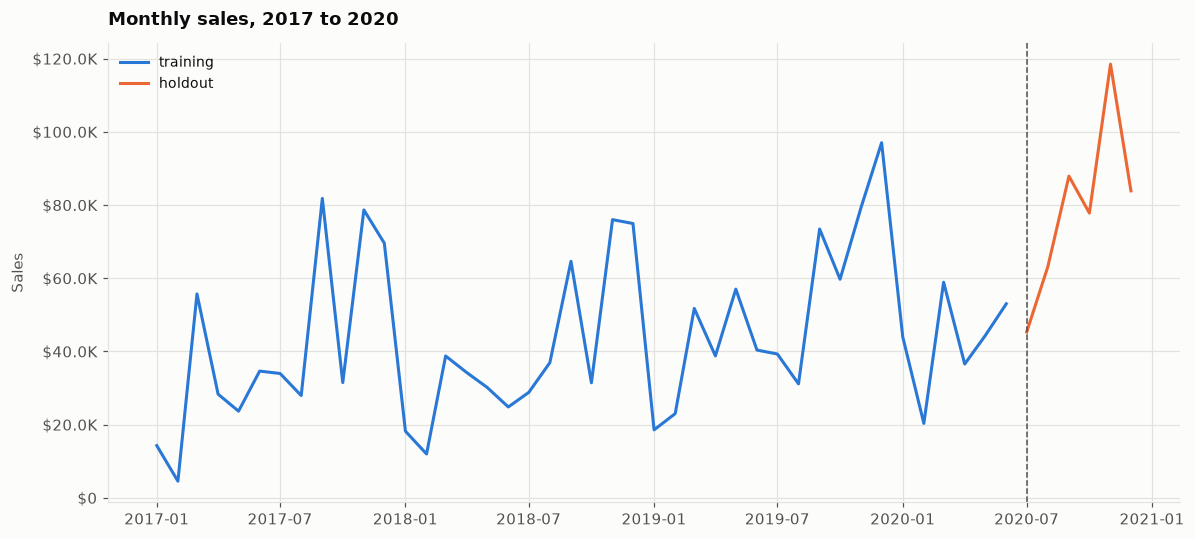

annual totals:
2017    $484,247
2018    $470,533
2019    $609,206
2020    $733,215


In [2]:
fig, ax = plt.subplots(figsize=(11, 5))

ax.plot(train.index, train.values, color=viz.CATEGORICAL[0], linewidth=2, label="training")
ax.plot(test.index, test.values, color=viz.CATEGORICAL[1], linewidth=2, label="holdout")
ax.axvline(test.index[0], color=viz.INK_MUTED, linewidth=1, linestyle="--")

ax.set_title("Monthly sales, 2017 to 2020")
ax.set_ylabel("Sales")
ax.yaxis.set_major_formatter(plt.FuncFormatter(viz.currency))
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
viz.save_figure(fig, "forecast_series")
plt.show()

annual = series.groupby(series.index.year).sum()
print("annual totals:")
print(annual.map(lambda v: f"${v:,.0f}").to_string())

Three features matter for the model choice.

**Strong annual seasonality.** Every year peaks in Q4 and troughs in Q1 and February in
particular. Any model without a seasonal term will be badly wrong twice a year.

**An upward trend**, though not a smooth one. 2018 was slightly below 2017 before growth
resumed.

**Only 48 observations.** That is four seasonal cycles, the bare minimum for estimating annual
seasonality. It is the single biggest constraint on how confident this forecast can be.

## Backtest

In [3]:
result = fc.backtest(series)
result.table.round(2)

C:\Users\Nick\Desktop\Portfolio Project 2\Project-2-superstore-sales-analytics\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
22:32:17 - cmdstanpy - INFO - Chain [1] start processing


22:32:17 - cmdstanpy - INFO - Chain [1] done processing


,model,mape_pct,rmse,note
0,SARIMA,18.02,17960.11,"(1,1,1)(1,1,0,12)"
1,Prophet,18.55,20762.50,yearly seasonality
2,Seasonal naive,25.39,23430.16,last year's same month


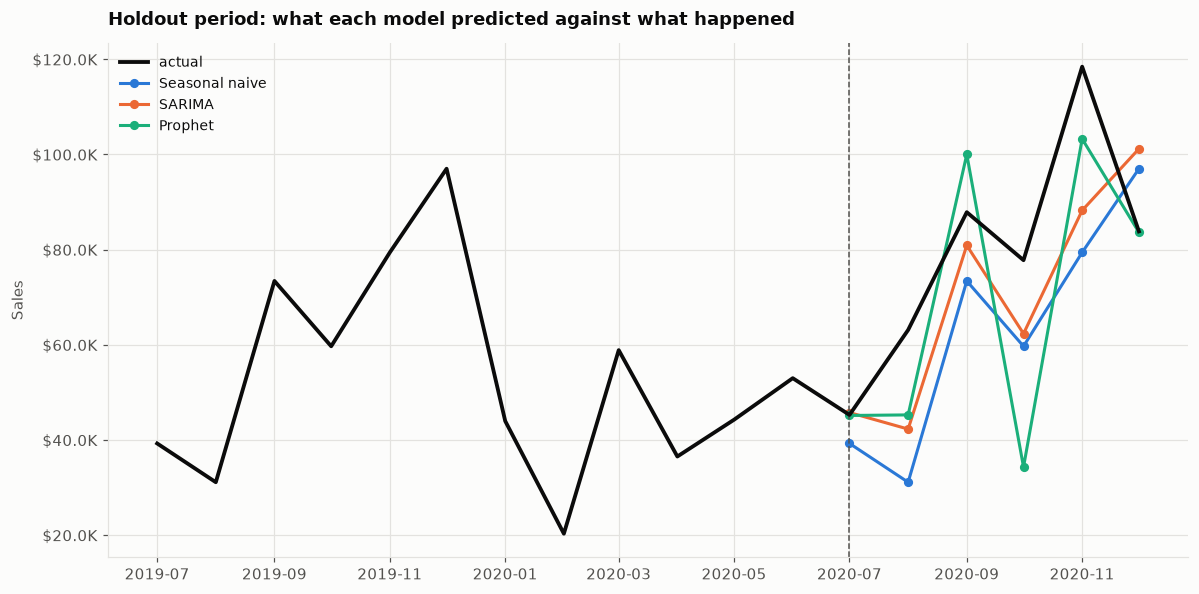

In [4]:
fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(series.index[-18:], series.values[-18:], color=viz.INK, linewidth=2.5,
        label="actual", zorder=5)

for (name, forecast), color in zip(result.forecasts.items(), viz.CATEGORICAL):
    ax.plot(forecast.predicted.index, forecast.predicted.values, color=color,
            linewidth=2, marker="o", markersize=5, label=name)

ax.axvline(test.index[0], color=viz.INK_MUTED, linewidth=1, linestyle="--")
ax.set_title("Holdout period: what each model predicted against what happened")
ax.set_ylabel("Sales")
ax.yaxis.set_major_formatter(plt.FuncFormatter(viz.currency))
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
viz.save_figure(fig, "forecast_backtest")
plt.show()

**SARIMA wins with an 18.0% MAPE**, against 18.6% for Prophet and 25.4% for the naive
baseline. The statistical models beat the baseline by roughly 29%, so the complexity is
earning its place, though not overwhelmingly.

An 18% MAPE is honest but not impressive, and it should be quoted with the forecast rather
than buried. On a $50,000 month it implies a typical miss of about $9,000. That is fine for
capacity planning and wrong for anything that needs precision.

Prophet finishing within half a point of SARIMA on 42 training months is the expected result:
its strength is many observations and multiple seasonalities, and neither is available here.

## Next quarter

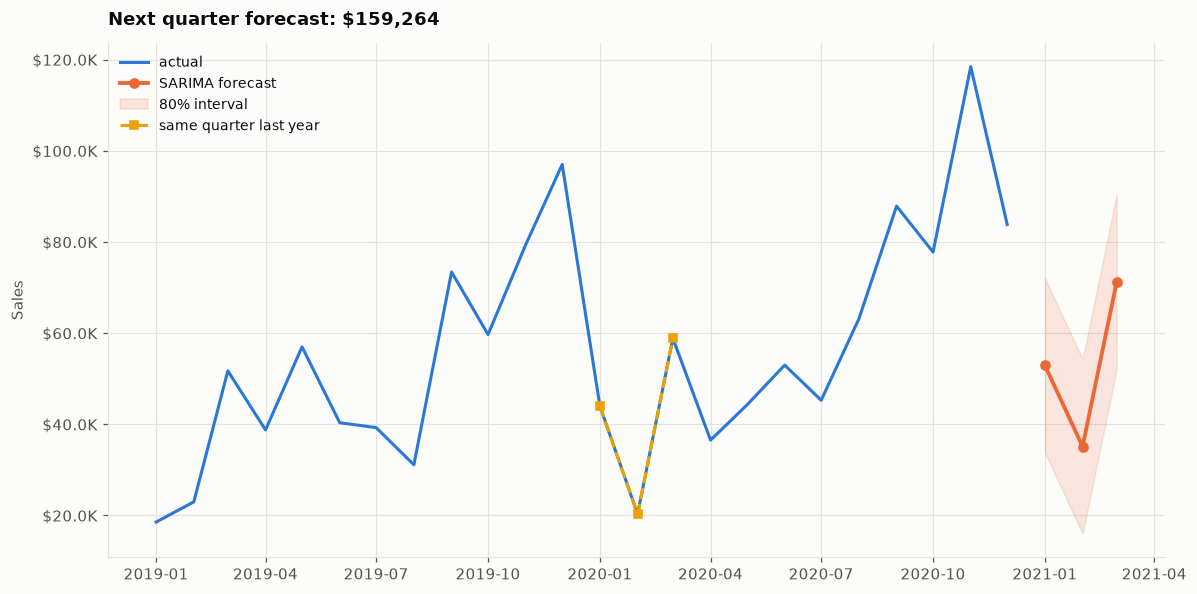

,month,forecast,lower_80,upper_80
0,2021-01,52929.03,33805.68,72052.39
1,2021-02,35122.09,15998.81,54245.37
2,2021-03,71212.84,52041.64,90384.05


In [5]:
best = result.best
forecast = fc.forecast_next_quarter(series, best)

fig, ax = plt.subplots(figsize=(11, 5.5))

ax.plot(series.index[-24:], series.values[-24:], color=viz.CATEGORICAL[0], linewidth=2,
        label="actual")
ax.plot(forecast.predicted.index, forecast.predicted.values, color=viz.CATEGORICAL[1],
        linewidth=2.5, marker="o", markersize=6, label=f"{best} forecast")
ax.fill_between(forecast.predicted.index, forecast.lower.values, forecast.upper.values,
                color=viz.CATEGORICAL[1], alpha=0.15, label="80% interval")

# Same quarter a year earlier, the only fair comparison for a seasonal business.
last_year = series.tail(12).head(3)
ax.plot(last_year.index, last_year.values, color=viz.CATEGORICAL[3], linewidth=2,
        linestyle="--", marker="s", markersize=5, label="same quarter last year")

ax.set_title(f"Next quarter forecast: ${forecast.predicted.sum():,.0f}")
ax.set_ylabel("Sales")
ax.yaxis.set_major_formatter(plt.FuncFormatter(viz.currency))
ax.legend(loc="upper left", fontsize=9)

fig.tight_layout()
viz.save_figure(fig, "forecast_next_quarter")
plt.show()

pd.DataFrame({
    "month": [d.strftime("%Y-%m") for d in forecast.predicted.index],
    "forecast": forecast.predicted.values,
    "lower_80": forecast.lower.values,
    "upper_80": forecast.upper.values,
}).round(2)

**Q1 2021 forecasts at $159,264, with an 80% interval from $101,846 to $216,682.**

The comparison to use is the same quarter a year earlier, $123,145, which makes this **+29%
year over year**. Comparing it instead to the $280,054 of the quarter just ended would suggest
the business is collapsing, when all it shows is that Q4 is the peak and Q1 is the trough.

The interval is wide, spanning roughly a third either side of the point estimate. With 48
months of history that width is the truthful answer, and narrowing it would mean overstating
what the data supports.

## By region

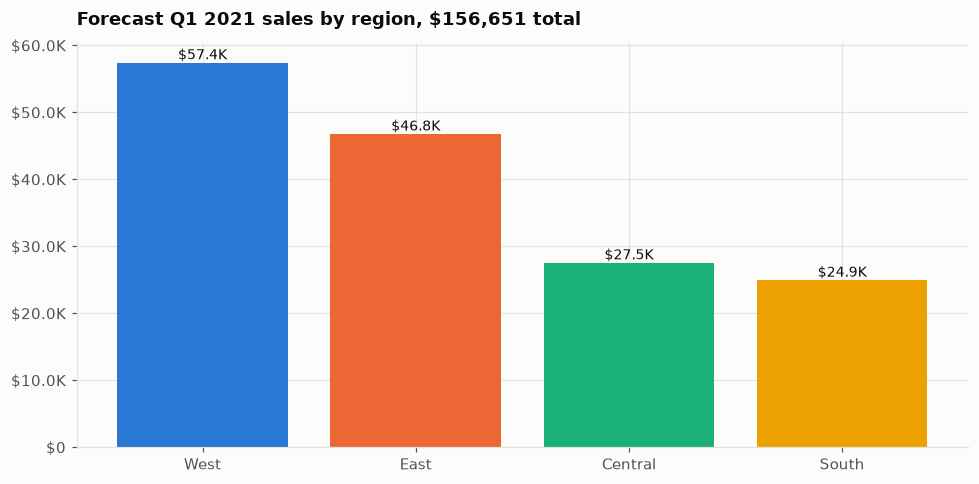

,region,month,forecast_sales,lower_80,upper_80
0,Central,2021-01,14566.12,3087.23,26045.02
1,Central,2021-02,379.92,0.00,11933.12
2,Central,2021-03,12588.45,506.43,24670.47
3,East,2021-01,14463.34,2923.04,26003.63
4,East,2021-02,9410.60,0.00,21158.97
5,East,2021-03,22893.01,10333.23,35452.80
6,South,2021-01,7991.16,0.00,17147.20
7,South,2021-02,7054.18,0.00,16231.13
8,South,2021-03,9897.86,644.15,19151.58
9,West,2021-01,14448.58,6468.05,22429.11


In [6]:
regional = fc.regional_forecasts(best)
totals = regional.groupby("region")["forecast_sales"].sum().sort_values(ascending=False)

fig, ax = plt.subplots(figsize=(9, 4.5))
ax.bar(totals.index, totals.values, color=[viz.REGION_COLORS[r] for r in totals.index])
ax.set_title(f"Forecast Q1 2021 sales by region, ${totals.sum():,.0f} total")
ax.yaxis.set_major_formatter(plt.FuncFormatter(viz.currency))
for x, v in enumerate(totals.values):
    ax.annotate(viz.currency(v), (x, v), ha="center", va="bottom", fontsize=9, color=viz.INK)

fig.tight_layout()
viz.save_figure(fig, "forecast_by_region")
plt.show()

regional.round(2)

The West forecasts strongest, which matches its recent trajectory: +34% sales growth in 2019
and +33% in 2020, at the healthiest margin of the four regions.

These regional numbers are much less trustworthy than the national one. Each is fitted on a
quarter of the volume, the seasonal signal is correspondingly weaker, and several monthly
intervals reach zero after being floored there. They are useful as a split of the national
forecast, not as four independent predictions.

## Conclusion

**Next quarter forecasts at $159,264, plus or minus roughly $57,000 at 80% confidence, which
is 29% up year over year.**

Three things to carry into any conversation about this number:

1. **The model has an 18% typical error.** Quote it alongside the forecast every time.
2. **The comparison that matters is year over year**, because Q1 is the seasonal trough.
3. **This forecasts revenue, not profit.** Given that margin is driven almost entirely by
   discounting, growing sales into the same discount practices would grow the losses too. The
   forecast is a capacity number, not a profit number.